# Decision Tree Regression and Handling Missing Values

This section explores Decision Tree Regression using the Diabetes dataset.

The following tasks are performed:

- Train a Decision Tree Regressor using the squared error criterion.
- Experiment with different tree depths.
- Evaluate models using MAE and RMSE.
- Simulate missing data by randomly removing 10% of the values in one feature.
- Handle missing values using:
  - Mean imputation
  - SimpleImputer from scikit-learn
- Compare the model performance before and after handling missing values.

## 1. Load the Diabetes Dataset

The Diabetes dataset provided by scikit-learn is used for the regression task.

The input features are numerical measurements, and the target represents a quantitative disease progression measure.

In [24]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [25]:
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()

X = pd.DataFrame(
    diabetes.data,
    columns=diabetes.feature_names
)

y = pd.Series(
    diabetes.target,
    name="target"
)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeature names:")
print(X.columns.tolist())

X shape: (442, 10)
y shape: (442,)

Feature names:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


## 2. Inspect the Dataset

Before training the regression model, we check the basic structure and whether the dataset already contains missing values.

In [26]:
print("Missing values:")
print(X.isnull().sum())

print("\nDataset summary:")
X.describe()

Missing values:
age    0
sex    0
bmi    0
bp     0
s1     0
s2     0
s3     0
s4     0
s5     0
s6     0
dtype: int64

Dataset summary:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.268604e-17,1.130318e-17
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01


## 3. Train-Test Split

The dataset is divided into training and testing sets.

The test set is kept separate from the training process so that the final model can be evaluated on unseen data.

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (353, 10)
Test set: (89, 10)


## 4. Train a Decision Tree Regressor

A Decision Tree Regressor is trained using the squared error criterion.

The squared error criterion selects splits that minimize the weighted squared error within the resulting child nodes.

In [28]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(
    criterion="squared_error",
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Model trained successfully.")

Model trained successfully.


## 5. Evaluate the Regression Model

Two evaluation metrics are used:

- **MAE (Mean Absolute Error)** measures the average absolute difference between predicted and actual values.
- **RMSE (Root Mean Squared Error)** is the square root of the mean squared error and gives more weight to larger errors.

In [29]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 54.52808988764045
RMSE: 70.54642267903446


## 6. Experiment with Different Tree Depths

The maximum depth of a Decision Tree controls its complexity.

Several values of `max_depth` are tested to observe how tree depth affects MAE and RMSE.

In [30]:
depths = [2, 3, 4, 5, 6, 8, 10]

depth_results = []

for depth in depths:
    model = DecisionTreeRegressor(
        criterion="squared_error",
        max_depth=depth,
        random_state=42
    )

    model.fit(
        X_train,
        y_train
    )

    prediction = model.predict(X_test)

    mae = mean_absolute_error(
        y_test,
        prediction
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            prediction
        )
    )

    depth_results.append({
        "Max Depth": depth,
        "MAE": mae,
        "RMSE": rmse
    })

depth_results = pd.DataFrame(depth_results)

depth_results

,Max Depth,MAE,RMSE
0,2,49.365345,61.118734
1,3,48.096592,59.604541
2,4,47.045392,59.740817
3,5,45.936955,59.380262
4,6,47.474976,60.586036
5,8,48.724558,61.827558
6,10,52.451158,66.241839


### Depth Experiment

A shallow tree has limited complexity and may underfit the training data.

As the maximum depth increases, the tree can model more complex relationships. However, an excessively deep tree may become sensitive to the training data and potentially overfit.

The MAE and RMSE values are used to observe the effect of tree depth on test performance.

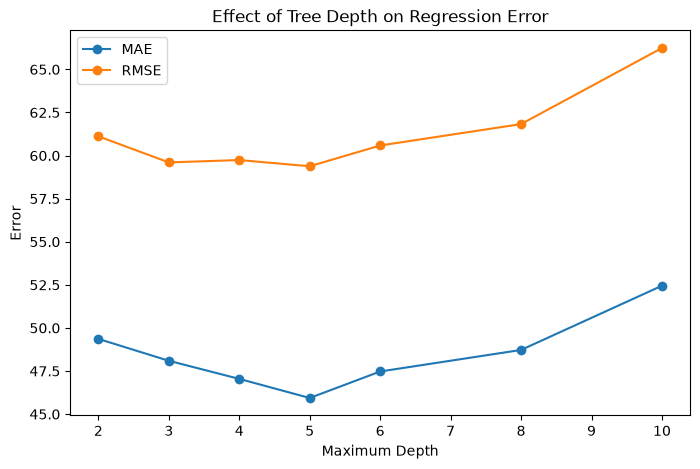

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(
    depth_results["Max Depth"],
    depth_results["MAE"],
    marker="o",
    label="MAE"
)

plt.plot(
    depth_results["Max Depth"],
    depth_results["RMSE"],
    marker="o",
    label="RMSE"
)

plt.xlabel("Maximum Depth")
plt.ylabel("Error")
plt.title("Effect of Tree Depth on Regression Error")
plt.legend()
plt.show()

## 7. Simulate Missing Data

The original Diabetes dataset does not contain missing values.

To study the effect of missing data, 10% of the values in one feature are randomly replaced with missing values (`NaN`).

The feature `bmi` is selected for this experiment.

In [32]:
X_missing = X.copy()

np.random.seed(42)

missing_indices = np.random.choice(
    X_missing.index,
    size=int(0.10 * len(X_missing)),
    replace=False
)

X_missing.loc[
    missing_indices,
    "bmi"
] = np.nan

print(
    "Number of missing values in bmi:",
    X_missing["bmi"].isnull().sum()
)

print(
    "Missing percentage:",
    X_missing["bmi"].isnull().mean() * 100,
    "%"
)

Number of missing values in bmi: 44
Missing percentage: 9.95475113122172 %


## 8. Inspect the Simulated Missing Data

The missing values are visualized by comparing the number of missing values before and after the simulation.

In [33]:
print("Missing values before simulation:")
print(X.isnull().sum())

print("\nMissing values after simulation:")
print(X_missing.isnull().sum())

Missing values before simulation:
age    0
sex    0
bmi    0
bp     0
s1     0
s2     0
s3     0
s4     0
s5     0
s6     0
dtype: int64

Missing values after simulation:
age     0
sex     0
bmi    44
bp      0
s1      0
s2      0
s3      0
s4      0
s5      0
s6      0
dtype: int64


## 9. Handling Missing Values with Mean Imputation

The missing `bmi` values are replaced by the mean of the available `bmi` values.

The mean is calculated from the training data to avoid using information from the test set.

In [34]:
X_train_missing, X_test_missing, y_train_missing, y_test_missing = train_test_split(
    X_missing,
    y,
    test_size=0.2,
    random_state=42
)

bmi_mean = X_train_missing["bmi"].mean()

X_train_mean = X_train_missing.copy()
X_test_mean = X_test_missing.copy()

X_train_mean["bmi"] = X_train_mean["bmi"].fillna(bmi_mean)
X_test_mean["bmi"] = X_test_mean["bmi"].fillna(bmi_mean)

print("Mean bmi:", bmi_mean)

print(
    "\nMissing values in training set:",
    X_train_mean.isnull().sum().sum()
)

print(
    "Missing values in test set:",
    X_test_mean.isnull().sum().sum()
)

Mean bmi: 0.001735658340578064

Missing values in training set: 0
Missing values in test set: 0


## 10. Handling Missing Values with SimpleImputer

`SimpleImputer` from scikit-learn is used with the `mean` strategy.

The imputer is fitted on the training data and then used to transform both the training and test sets.

In [35]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(
    strategy="mean"
)

# fit on trainin data first
X_train_simple = pd.DataFrame(
    imputer.fit_transform(X_train_missing),
    columns=X_train_missing.columns,
    index=X_train_missing.index
)

# perform on test set (NO fit because can cause Data leakage)
X_test_simple = pd.DataFrame(
    imputer.transform(X_test_missing),
    columns=X_test_missing.columns,
    index=X_test_missing.index
)

print(
    "Missing values in training set:",
    X_train_simple.isnull().sum().sum()
)

print(
    "Missing values in test set:",
    X_test_simple.isnull().sum().sum()
)

Missing values in training set: 0
Missing values in test set: 0


## 11. Train Decision Tree with Mean Imputation

A Decision Tree Regressor is trained on the dataset after manually replacing missing values with the training-set mean.

In [36]:
model_mean = DecisionTreeRegressor(
    criterion="squared_error",
    random_state=42
)

model_mean.fit(
    X_train_mean,
    y_train_missing
)

prediction_mean = model_mean.predict(
    X_test_mean
)

## 12. Evaluate Mean Imputation

The model using mean imputation is evaluated using MAE and RMSE.

In [37]:
mae_mean = mean_absolute_error(
    y_test_missing,
    prediction_mean
)

rmse_mean = np.sqrt(
    mean_squared_error(
        y_test_missing,
        prediction_mean
    )
)

print("Mean Imputation")
print("MAE:", mae_mean)
print("RMSE:", rmse_mean)

Mean Imputation
MAE: 58.38202247191011
RMSE: 73.17410360368105


## 13. Train Decision Tree with SimpleImputer

The same Decision Tree Regressor is trained using the data processed by `SimpleImputer(strategy="mean")`.

In [38]:
model_simple = DecisionTreeRegressor(
    criterion="squared_error",
    random_state=42
)

model_simple.fit(
    X_train_simple,
    y_train_missing
)

prediction_simple = model_simple.predict(
    X_test_simple
)

## 14. Evaluate SimpleImputer

The model using `SimpleImputer` is evaluated using the same MAE and RMSE metrics.

In [39]:
mae_simple = mean_absolute_error(
    y_test_missing,
    prediction_simple
)

rmse_simple = np.sqrt(
    mean_squared_error(
        y_test_missing,
        prediction_simple
    )
)

print("SimpleImputer")
print("MAE:", mae_simple)
print("RMSE:", rmse_simple)

SimpleImputer
MAE: 58.38202247191011
RMSE: 73.17410360368105


## 15. Compare Missing Value Handling Methods

The performance of the models using the two missing-value handling methods is compared using MAE and RMSE.

For both metrics, lower values indicate smaller prediction errors.

In [40]:
comparison = pd.DataFrame({
    "Method": [
        "Mean Imputation",
        "SimpleImputer"
    ],
    "MAE": [
        mae_mean,
        mae_simple
    ],
    "RMSE": [
        rmse_mean,
        rmse_simple
    ]
})

comparison

,Method,MAE,RMSE
0,Mean Imputation,58.382022,73.174104
1,SimpleImputer,58.382022,73.174104


## 16. Compare with the Original Dataset

The model trained on the original dataset is also included as a reference.

This allows us to examine how the simulated missing values and the subsequent imputation affect regression performance.

In [41]:
final_comparison = pd.DataFrame({
    "Method": [
        "Original Data",
        "10% Missing + Mean Imputation",
        "10% Missing + SimpleImputer"
    ],
    "MAE": [
        mae,
        mae_mean,
        mae_simple
    ],
    "RMSE": [
        rmse,
        rmse_mean,
        rmse_simple
    ]
})

final_comparison

,Method,MAE,RMSE
0,Original Data,52.451158,66.241839
1,10% Missing + Mean Imputation,58.382022,73.174104
2,10% Missing + SimpleImputer,58.382022,73.174104


## 17. Visualization of Model Performance

The MAE and RMSE values are visualized to make the effect of missing-value handling easier to compare.

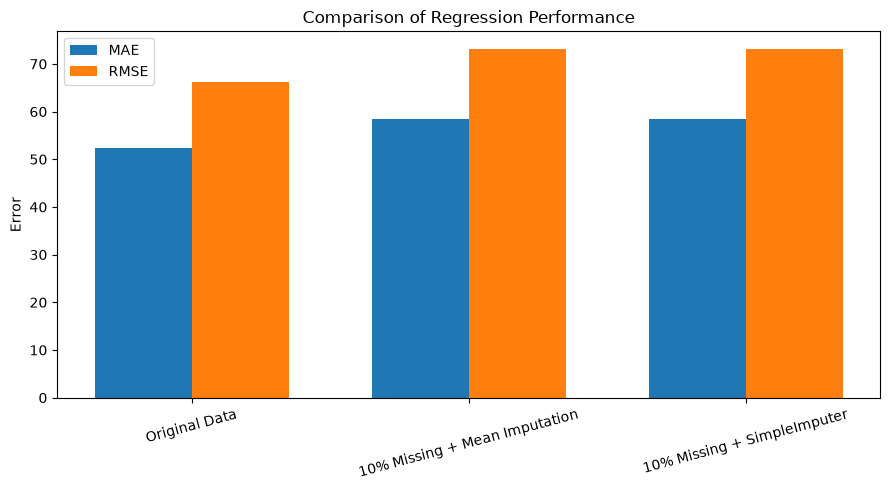

In [42]:
plt.figure(figsize=(9, 5))

x = np.arange(len(final_comparison))
width = 0.35

plt.bar(
    x - width / 2,
    final_comparison["MAE"],
    width,
    label="MAE"
)

plt.bar(
    x + width / 2,
    final_comparison["RMSE"],
    width,
    label="RMSE"
)

plt.xticks(
    x,
    final_comparison["Method"],
    rotation=15
)

plt.ylabel("Error")
plt.title("Comparison of Regression Performance")
plt.legend()
plt.tight_layout()
plt.show()

## Conclusion

A Decision Tree Regressor using the squared error criterion was trained on the Diabetes dataset.

Different maximum tree depths were evaluated using MAE and RMSE to examine the effect of tree complexity on regression performance.

To study missing-data handling, 10% of the values in the `bmi` feature were randomly removed. The missing values were then handled using two approaches:

1. Mean imputation using the training-set mean.
2. `SimpleImputer` with the `mean` strategy.

The resulting models were evaluated using MAE and RMSE and compared with the model trained on the original dataset.

Mean imputation and `SimpleImputer(strategy="mean")` use the same underlying imputation strategy, so their results are expected to be identical or extremely close. The comparison with the original-data model shows the impact of introducing missing values and subsequently imputing them.